In [2]:
from kan import *
torch.set_default_dtype(torch.float64)
import torch
from torch.quantization import QuantStub, DeQuantStub
import matplotlib.pyplot as plt
import numpy as np
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).

cuda


Create dataset

In [3]:
from kan.utils import create_dataset
from torch.distributions.normal import Normal

eps = 1e-6

# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)

In [4]:
# Dataset Specific
n_var = 5
train_num = 10_000
test_num = 10_000

#Model Specific
seed = 42
grid_size = 16
grid_range = [-1, 1]
spline_order = 3
hidden_dim = [11, 11]
out_dim = 1

# Training Specfic
batch_size = -1
training_steps = 1000
opt = 'Adam'
lr = 0.001



dataset = create_dataset(f, n_var=n_var, train_num=train_num, test_num=test_num, device=device)
dataset['train_input'].shape, dataset['train_label'].shape


(torch.Size([10000, 5]), torch.Size([10000, 1]))

In [5]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastMPKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device)
fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

| train_loss: 5.94e-01 | test_loss: 5.03e-01 | :   0%|             | 1/1000 [00:00<04:45,  3.50it/s]STAGE:2025-05-11 07:52:23 130592:130592 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 5.55e-01 | test_loss: 4.71e-01 | :   0%|             | 1/1000 [00:00<04:45,  3.50it/s][W CPUAllocator.cpp:235] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event
| train_loss: 5.04e-01 | test_loss: 4.30e-01 | :   0%|             | 1/1000 [00:00<04:45,  3.50it/s]STAGE:2025-05-11 07:52:23 130592:130592 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-11 07:52:23 130592:130592 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.55e-01 | test_loss: 6.68e-02 | : 100%|██████████| 1000/1000 [00:17<00:00, 57.36it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        28.20%      25.316ms        90.21%      80.997ms      26.999ms       0.000us         0.00%      36.986ms      12.329ms      78.17 Kb    -156.30 Kb           0 b      -1.04 G

AttributeError: 'FunctionEventAvg' object has no attribute 'is_user_annotation'

Train KAN with sparsity regularization

In [60]:
# train the kan_model
# Initialize W&B project
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Vanilla KAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device)

kan_metrics = kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.70e-02 | test_loss: 7.98e-02 | reg: 9.92e+00 |: 100%|█| 1000/1000 [01:49<00:00,  9.1


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     146.951ms        47.01%     146.951ms      48.984ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▇▁▄▆▃▁▂▂▃▁▄▃▄▁▃▃▆▁▂▂▂▁▆▆▂▄▃▂▃▂▅▂▃▃▆█▂▇▃▂
reg,█▆▆▆▆▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇██████
train_loss,█▅▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1300.24376
cuda_time_total (ms),312.59258


In [61]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Mixed Precision KAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device)

mpkan_metrics = mpkan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(opt == "Adam"))
/content/drive/MyDrive/optimized_kan/kan/MixedKAN.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
| train_loss: 4.70e-02 | test_loss: 8.13e-02 | reg: 9.11e+00 |: 100%|█| 1000/1000 [01:49<00:00,  9.0


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     360.548ms       134.08%     360.548ms     120.183ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,█▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,██▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
train_loss,█▇▇▇▆▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1142.63276
cuda_time_total (ms),268.90624


In [62]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Vanilla KAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})


compiled_kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True)

compiled_kan_metrics = compiled_kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)
run.finish()


checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.60e-02 | test_loss: 8.03e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:34<00:00, 10.5


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     116.519ms        39.54%     116.519ms      38.840ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▅▃▂▅▆▄▄▄▄▅▄█▃▅▃▆▅▄▄▃▅▁▅▃▂▃▃▅▂▁▂▃▆▅▄▃▅▃▂▃
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇███
train_loss,█▆▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1160.71676
cuda_time_total (ms),294.67734


In [63]:
# train the kan_model
# Initialize W&B project
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Mixed Precision KAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device)

compiled_mpkan_metrics = kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.65e-02 | test_loss: 8.64e-02 | reg: 8.27e+00 |: 100%|█| 1000/1000 [01:48<00:00,  9.2


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     142.365ms        44.95%     142.365ms      47.455ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,█▁▁▁▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,██▇▆▅▄▄▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇███
train_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),1314.12212
cuda_time_total (ms),316.74863


In [64]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Vanilla KAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_opt_kan_model = KAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

compiled_opt_kan_metrics = compiled_opt_kan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.60e-02 | test_loss: 8.02e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:34<00:00, 10.5


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     116.939ms        39.69%     116.939ms      38.980ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▂▁▂▃▂▂▅▂▂▂▂▂▂▁▂▂▃▂▂▁▂▁▂▂▁▁▂▄▂▁▂▂▁▂▁▂█▁▁▂
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train_loss,██▇▇▇▇▅▅▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▂▂▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
cpu_time_total (ms),1172.33409
cuda_time_total (ms),294.60392


In [65]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="Mixed Precision KAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "spline_order":spline_order,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

compiled_opt_mpkan_model = MPKAN(width=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid=wandb.config.grid_size,
                grid_range=wandb.config.grid_range,
                k=wandb.config.spline_order,
                seed=wandb.config.seed,
                device=device).speed(compile=True, dynamic=False, fullgraph=True, options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})

compiled_opt_mpkan_metrics = compiled_opt_mpkan_model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

checkpoint directory created: ./model
saving model version 0.0
setting lamb=0. If you want to set lamb > 0, set self.save_act=True


| train_loss: 1.63e-02 | test_loss: 8.03e-02 | reg: 0.00e+00 |: 100%|█| 1000/1000 [01:35<00:00, 10.4


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     296.680ms       121.42%     296.680ms      98.893ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train_loss,█▆▆▆▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▅▄▄▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),962.22011
cuda_time_total (ms),244.35012


In [5]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device)
fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

| train_loss: 5.94e-01 | test_loss: 5.03e-01 | :   0%|             | 1/1000 [00:00<04:42,  3.54it/s]STAGE:2025-05-11 07:39:06 123164:123164 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 5.55e-01 | test_loss: 4.71e-01 | :   0%|             | 1/1000 [00:00<04:42,  3.54it/s][W CPUAllocator.cpp:235] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event
| train_loss: 5.04e-01 | test_loss: 4.30e-01 | :   0%|             | 4/1000 [00:00<01:21, 12.15it/s]STAGE:2025-05-11 07:39:06 123164:123164 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-11 07:39:06 123164:123164 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.55e-01 | test_loss: 6.68e-02 | : 100%|██████████| 1000/1000 [00:18<00:00, 53.85it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.14%       1.438ms         1.60%       2.025ms      42.188us      48.459ms        53.03%      48.459ms       1.010ms           0 b           0 b      99.64 Mb      99.64 M

AttributeError: 'FunctionEventAvg' object has no attribute 'is_user_annotation'

In [7]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastMPKAN",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device)
fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exec_time,██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▆▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▆▆▅▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exec_time,0.0154
step,999
train_loss,0.15482
val_loss,0.06684


| train_loss: 5.90e-01 | test_loss: 4.99e-01 | :   0%|                     | 0/1000 [00:00<?, ?it/s]STAGE:2025-05-11 07:51:29 129956:129956 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 5.05e-01 | test_loss: 4.28e-01 | :   0%|             | 4/1000 [00:00<00:32, 30.60it/s]STAGE:2025-05-11 07:51:29 129956:129956 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-11 07:51:29 129956:129956 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.52e-01 | test_loss: 6.00e-02 | : 100%|██████████| 1000/1000 [00:17<00:00, 57.09it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.11%       1.173ms         1.54%       1.633ms      34.021us      48.460ms        58.70%      48.460ms       1.010ms           0 b           0 b      99.64 Mb      99.64 M

AttributeError: 'FunctionEventAvg' object has no attribute 'is_user_annotation'

In [ ]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastKAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size
                              ).to(device),)
compiled_fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

| train_loss: 1.52e-01 | test_loss: 6.00e-02 | : 100%|██████████| 1000/1000 [00:19<00:00, 51.32it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      95.852ms       108.70%      95.852ms      31.951ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,█▅▂▄▄▄▄▆▁▁▅▁▂▂▁▂▂▁▂▂▁▃▂▂▂▆▂▆▄▅▁▂▃▃▁▂▂▂▂▂
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇██
train_loss,██▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▆▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),428.61781
cuda_time_total (ms),88.17626
exec_time,0.01646


In [ ]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastMPKAN Compiled",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                grid_min=wandb.config.grid_range[0],
                grid_max=wandb.config.grid_range[1],
                num_grids=wandb.config.grid_size).to(device))
fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)


run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exec_time,▃▃▁▃▃▂▄▂▃▆▄▃▃▅▃▄▅▄█▅▅▅▇▅▅▆▆▅▅▅▆▄▆▅▆▆▄▅▅▅
step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
train_loss,██▇▆▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exec_time,0.0155
step,999
train_loss,0.15055
val_loss,0.06022


| train_loss: 6.58e-01 | test_loss: 5.68e-01 | :   0%|                     | 0/1000 [00:00<?, ?it/s]STAGE:2025-05-11 07:46:03 123164:123164 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 5.50e-01 | test_loss: 4.65e-01 | :   0%|             | 3/1000 [00:00<00:35, 28.30it/s]STAGE:2025-05-11 07:46:03 123164:123164 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-11 07:46:03 123164:123164 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.59e-01 | test_loss: 6.44e-02 | : 100%|██████████| 1000/1000 [00:17<00:00, 56.32it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.21%       1.280ms         1.67%       1.770ms      36.875us      48.461ms        58.67%      48.461ms       1.010ms           0 b           0 b      99.64 Mb      99.64 M

AttributeError: 'FunctionEventAvg' object has no attribute 'is_user_annotation'

In [ ]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastKAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device),
                      dynamic=False,
                      fullgraph=True,
                      options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})
compiled_opt_fastkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

| train_loss: 1.48e-01 | test_loss: 6.35e-02 | : 100%|██████████| 1000/1000 [00:18<00:00, 53.28it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us      62.720ms        68.41%      62.720ms      20.907ms           0 b           0 b           0 b           0 

cpu_time_total (ms),▁
cuda_time_total (ms),▁
exec_time,▄▂▂▁▂▂▁▂▄▁▂▃▂▁▁▃▂▁▁▆▂▄▅▂▂▂▃█▁▁▂▁▂▂▄▁▂▂▁▂
self_cpu_time_total (ms),▁
self_cuda_time_total (ms),▁
step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇██
train_loss,██▆▆▅▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cpu_time_total (ms),436.73086
cuda_time_total (ms),91.67711
exec_time,0.01649


In [12]:
run = wandb.init(
    entity="hpml_project_spring25",
    project="Profiling_Speedups",
    name="FastMPKAN Compiled w/ Options",
    config={
    "equation": "Black-Scholes Option Pricing",
    "n_var": n_var,
    "train_num": train_num,
    "test_num": test_num,

    "input_dim": n_var,
    "hidden_dim": hidden_dim,
    "out_dim": out_dim,
    "grid_size": grid_size,
    "grid_range": grid_range,
    "seed": seed,

    "optimizer": opt,
    "batch_size": batch_size,
    "training_steps": training_steps,
    "lr": lr,
})

model = torch.compile(FastMPKAN(layers_hidden=[wandb.config.input_dim, *wandb.config.hidden_dim, wandb.config.out_dim],
                              grid_min=wandb.config.grid_range[0],
                              grid_max=wandb.config.grid_range[1],
                              num_grids=wandb.config.grid_size).to(device),
                      dynamic=False,
                      fullgraph=True,
                      options={"trace.enabled":True, "trace.graph_diagram":False, "triton.cudagraphs":True})
compiled_opt_fastmpkan_metrics = model.fit(dataset,
                            opt=wandb.config.optimizer,
                            batch=wandb.config.batch_size,
                            steps=wandb.config.training_steps,
                            lr=wandb.config.lr,
                            lamb=0.001,
                            profile=True)

run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exec_time,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▇▇▇▇█████
train_loss,█▇▆▆▅▅▅▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,███▇▆▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exec_time,0.01553
step,999
train_loss,0.14775
val_loss,0.0591


| train_loss: 4.68e-01 | test_loss: 4.02e-01 | :   0%|                     | 0/1000 [00:00<?, ?it/s]STAGE:2025-05-11 07:48:59 123164:123164 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
| train_loss: 4.30e-01 | test_loss: 3.77e-01 | :   0%|             | 3/1000 [00:00<00:33, 29.45it/s]STAGE:2025-05-11 07:48:59 123164:123164 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-05-11 07:48:59 123164:123164 ActivityProfilerController.cpp:324] Completed Stage: Post Processing
| train_loss: 1.46e-01 | test_loss: 6.32e-02 | : 100%|██████████| 1000/1000 [00:17<00:00, 57.98it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.19%       1.289ms         1.67%       1.807ms      37.646us      48.448ms        58.67%      48.448ms       1.009ms           0 b           0 b      99.64 Mb      99.64 M

AttributeError: 'FunctionEventAvg' object has no attribute 'is_user_annotation'

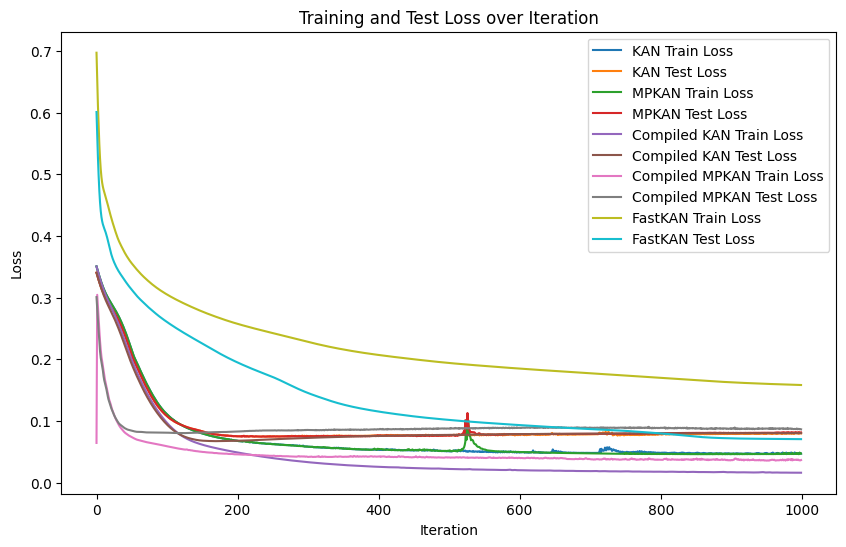

In [69]:
plt.figure(figsize=(10, 6))

plt.plot(np.array(kan_metrics['train_loss']), label='KAN Train Loss')
plt.plot(np.array(kan_metrics['test_loss']), label='KAN Test Loss')
plt.plot(np.array(mpkan_metrics['train_loss']), label='MPKAN Train Loss')
plt.plot(np.array(mpkan_metrics['test_loss']), label='MPKAN Test Loss')
plt.plot(np.array(compiled_kan_metrics['train_loss']), label='Compiled KAN Train Loss')
plt.plot(np.array(compiled_kan_metrics['test_loss']), label='Compiled KAN Test Loss')
plt.plot(np.array(compiled_mpkan_metrics['train_loss']), label='Compiled MPKAN Train Loss')
plt.plot(np.array(compiled_mpkan_metrics['test_loss']), label='Compiled MPKAN Test Loss')

plt.plot(np.array(fastkan_metrics['train_loss']), label='FastKAN Train Loss')
plt.plot(np.array(fastkan_metrics['test_loss']), label='FastKAN Test Loss')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Iteration')
plt.legend()  # No arguments needed; uses the labels above
plt.show()
